In [ ]:
import pandas as pd
import numpy as np

In [ ]:
cdf=pd.read_csv('/content/Lab 24 breast-cancer-wisconsin.csv')
cdf.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
cdf['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [ ]:
cdf.loc[cdf['diagnosis']=='M','benign_0_mal_1']=1
cdf.loc[cdf['diagnosis']=='B','benign_0_mal_1']=0


In [ ]:
cdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 34 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
#removing the cols-id,unamed:32 and diagnosis
cdf=cdf.drop(columns=['id','Unnamed: 32','diagnosis'])
cdf.columns

Index(['radius_mean', 'texture_mean', 'perimeter_mean', 'area_mean',
       'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'benign_0_mal_1'],
      dtype='object')

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

<Axes: xlabel='benign_0_mal_1', ylabel='count'>

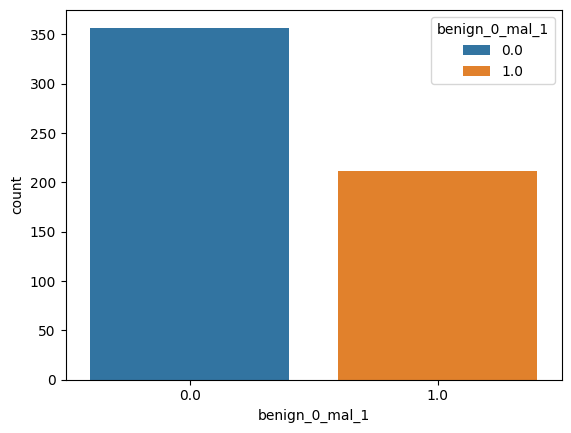

In [ ]:
sns.countplot(x='benign_0_mal_1',data=cdf,hue='benign_0_mal_1')

In [ ]:
cdf['benign_0_mal_1'].value_counts()

,count
benign_0_mal_1,
0.0,357
1.0,212


<Axes: >

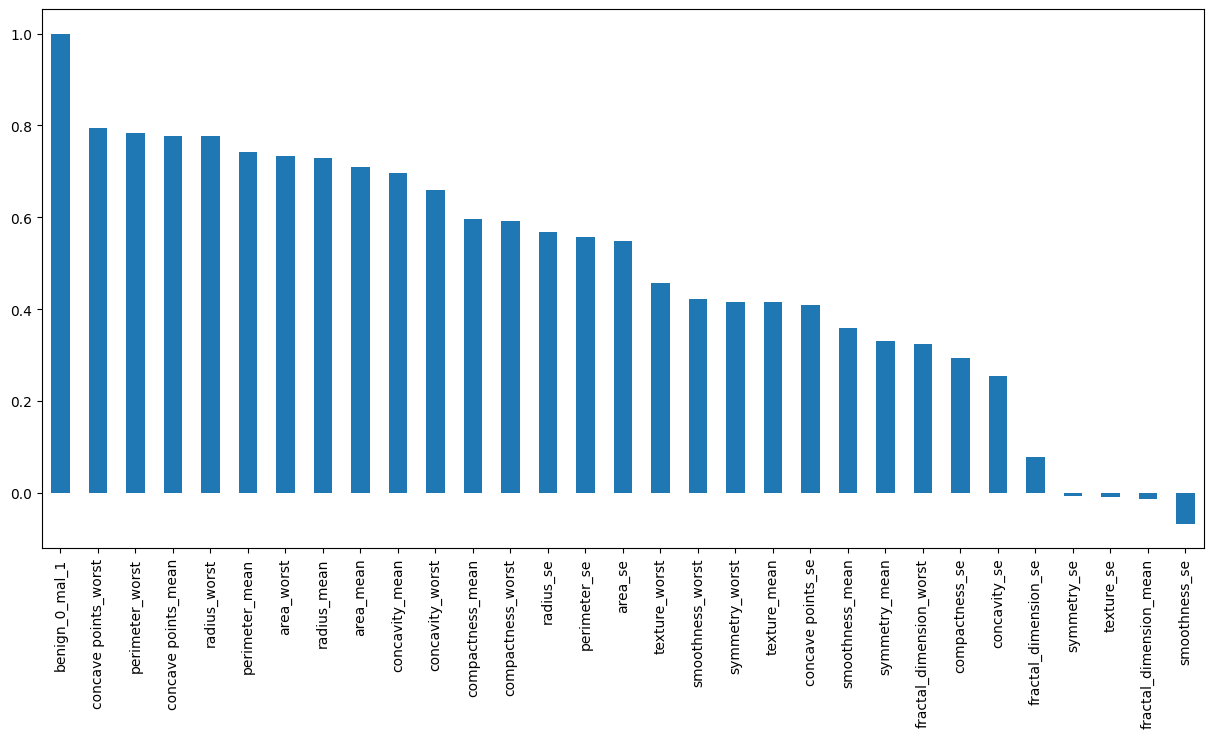

In [ ]:
plt.figure(figsize=(15,7))
cdf.corr()['benign_0_mal_1'].sort_values(ascending=False).plot(kind='bar')

In [ ]:
x=cdf.drop(['benign_0_mal_1'],axis=1).values
y=cdf['benign_0_mal_1'].values

In [ ]:
from sklearn.model_selection import train_test_split,cross_val_score

In [ ]:
xtr,xte,ytr,yte=train_test_split(x,y,train_size=0.8,random_state=50)

In [ ]:
xtr.shape,xte.shape

((455, 30), (114, 30))

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
xtr=scaler.fit_transform(xtr)
xte=scaler.transform(xte)  #prevent data likages

In [ ]:
!pip install tensorflow

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from  tensorflow.keras.layers import Dense,InputLayer,Dropout

In [ ]:
#create the model
model1=Sequential()
model1.add(InputLayer(input_shape=(30,)))#input layer with 26 input features
model1.add(Dense(26,activation='relu'))#First hiddenn layer
model1.add(Dense(15, activation='relu'))#Second hidden layer
model1.add(Dense(1, activation='sigmoid')) # Changed from 15 to 1 output unit
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 26)             │           806 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 15)             │           405 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,227 (4.79 KB)

 Trainable params: 1,227 (4.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [ ]:
model_loss=pd.DataFrame(model1.history.history)
model_loss.plot()

In [ ]:
model1.fit(x=xtr,y=ytr,epochs=100,validation_data=(xte,yte))

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.6330 - loss: 0.6721 - val_accuracy: 0.8333 - val_loss: 0.6591
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8791 - loss: 0.6457 - val_accuracy: 0.9211 - val_loss: 0.6265
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9011 - loss: 0.6109 - val_accuracy: 0.9123 - val_loss: 0.5874
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8835 - loss: 0.5709 - val_accuracy: 0.9211 - val_loss: 0.5393
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9187 - loss: 0.5220 - val_accuracy: 0.9035 - val_loss: 0.4919
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9187 - loss: 0.4725 - val_accuracy: 0.9211 - val_loss: 0.4338
Epoch 7/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9165 - loss: 0.4188 - val_accuracy: 0.9298 - val_loss: 0.3792
Epoch 8/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9121 - loss: 0.3689 - val_accuracy: 0.9386 - 

<Axes: >

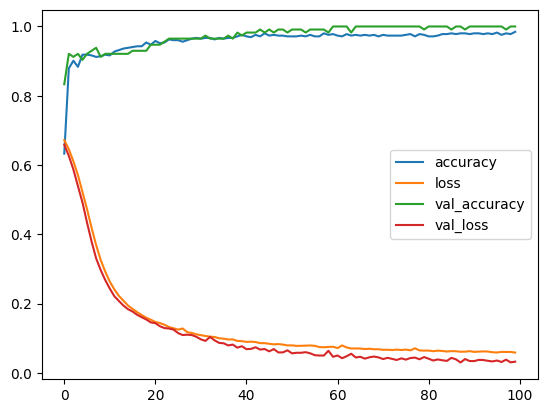

In [ ]:
model_loss=pd.DataFrame(model1.history.history)
model_loss.plot()